# 03 - Error Analysis

Deep dive into CLIP text-to-image retrieval failures on Flickr30k. We categorize errors by linguistic pattern, compare B/32 vs B/16 failures, analyze query hardness, and identify which error types fine-tuning could address.

**Depends on:** Cached embeddings from notebook 02.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

from src.config import DATA_DIR, EMBEDDINGS_DIR, TOP_K_VALUES
from src.data import load_karpathy_splits, get_all_captions_flat, get_image, get_captions
from src.clip_embeddings import load_embeddings
from src.retrieval import text_to_image_search, get_ranks, get_similarity_scores
from src.evaluation import recall_at_k, load_results
from src.visualize import (
    plot_retrieval_results,
    plot_rank_distribution,
    plot_error_analysis_grid,
    plot_text_image_similarity_distribution,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

In [2]:
# Load Karpathy splits
splits = load_karpathy_splits()
test_ds = splits["test"]
print(f"Test set: {len(test_ds)} images")

  train: 29000 images


  val: 1014 images
  test: 1000 images
Test set: 1000 images


In [3]:
# Load cached embeddings -- B/32
img_emb_b32 = load_embeddings("clip-vit-b-32_images", split="test")
txt_emb_b32 = load_embeddings("clip-vit-b-32_texts", split="test")
print(f"B/32 images: {img_emb_b32.shape}, texts: {txt_emb_b32.shape}")

# Load cached embeddings -- B/16
img_emb_b16 = load_embeddings("clip-vit-b-16_images", split="test")
txt_emb_b16 = load_embeddings("clip-vit-b-16_texts", split="test")
print(f"B/16 images: {img_emb_b16.shape}, texts: {txt_emb_b16.shape}")

B/32 images: (1000, 512), texts: (5000, 512)
B/16 images: (1000, 512), texts: (5000, 512)


In [4]:
# Flatten test captions + ground truth indices
captions, gt_indices = get_all_captions_flat(test_ds)
print(f"Total caption queries: {len(captions)}")
print(f"Unique images: {len(np.unique(gt_indices))}")
print(f"Sample caption: '{captions[0]}'")

Total caption queries: 5000
Unique images: 1000
Sample caption: 'The man with pierced ears is wearing glasses and an orange hat .'


## 2. Compute Full Rank Information

In [5]:
ranks_b32 = get_ranks(txt_emb_b32, img_emb_b32, gt_indices)
ranks_b16 = get_ranks(txt_emb_b16, img_emb_b16, gt_indices)

print("Rank summary (0-based):")
print(f"{'':>12} {'B/32':>10} {'B/16':>10}")
print(f"{'Mean':>12} {ranks_b32.mean():>10.1f} {ranks_b16.mean():>10.1f}")
print(f"{'Median':>12} {np.median(ranks_b32):>10.1f} {np.median(ranks_b16):>10.1f}")
print(f"{'Min':>12} {ranks_b32.min():>10d} {ranks_b16.min():>10d}")
print(f"{'Max':>12} {ranks_b32.max():>10d} {ranks_b16.max():>10d}")

Rank summary (0-based):
                   B/32       B/16
        Mean        5.1        4.0
      Median        0.0        0.0
         Min          0          0
         Max        507        334


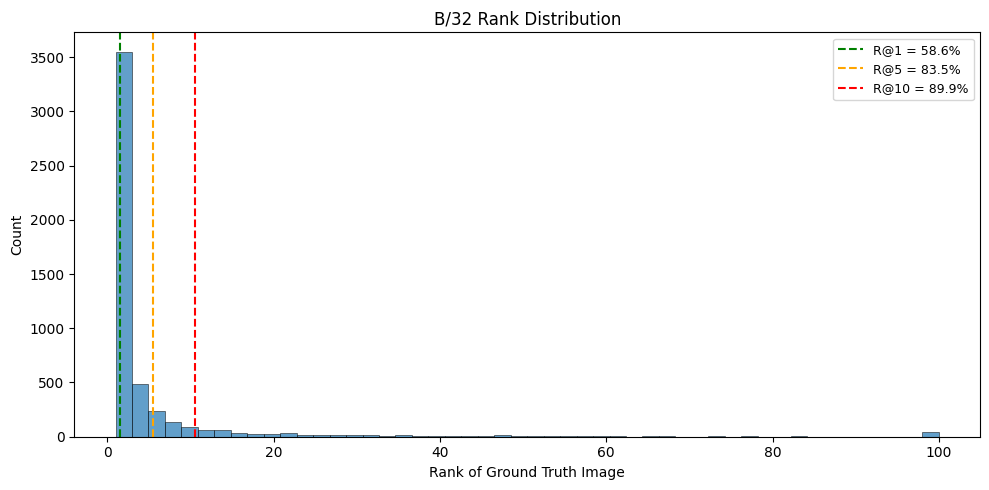

In [6]:
fig = plot_rank_distribution(ranks_b32, title="B/32 Rank Distribution")
plt.show()

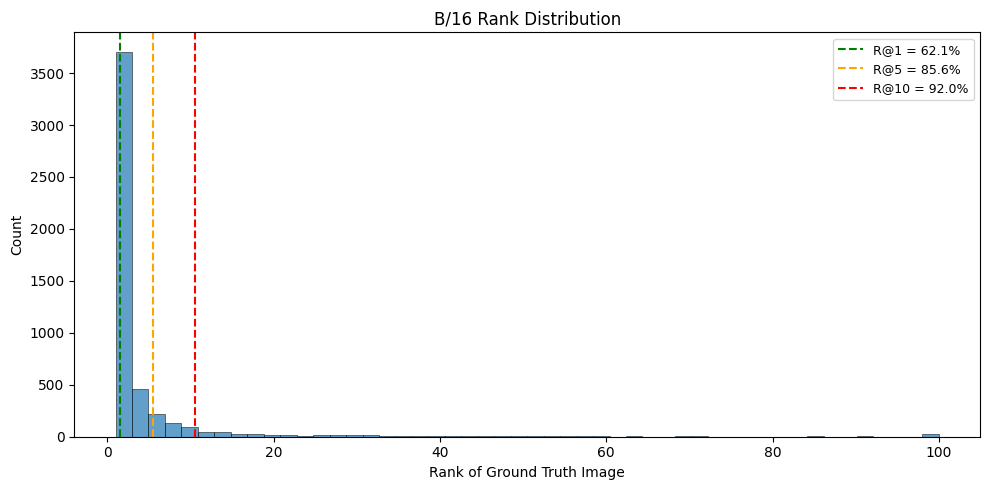

In [7]:
fig = plot_rank_distribution(ranks_b16, title="B/16 Rank Distribution")
plt.show()

In [8]:
# Near-miss / mid-range / far-miss breakdown
n_total = len(ranks_b32)

for name, ranks in [("B/32", ranks_b32), ("B/16", ranks_b16)]:
    exact = (ranks == 0).sum()
    near_miss = ((ranks >= 1) & (ranks <= 5)).sum()
    mid_range = ((ranks > 5) & (ranks <= 50)).sum()
    far_miss = (ranks > 50).sum()

    print(f"\n{name} breakdown:")
    print(f"  Exact match (rank 0):   {exact:5d} ({exact / n_total * 100:5.1f}%)")
    print(f"  Near-miss (rank 1-5):   {near_miss:5d} ({near_miss / n_total * 100:5.1f}%)")
    print(f"  Mid-range (rank 6-50):  {mid_range:5d} ({mid_range / n_total * 100:5.1f}%)")
    print(f"  Far-miss  (rank 50+):   {far_miss:5d} ({far_miss / n_total * 100:5.1f}%)")


B/32 breakdown:
  Exact match (rank 0):    2929 ( 58.6%)
  Near-miss (rank 1-5):    1338 ( 26.8%)
  Mid-range (rank 6-50):    623 ( 12.5%)
  Far-miss  (rank 50+):     110 (  2.2%)

B/16 breakdown:
  Exact match (rank 0):    3103 ( 62.1%)
  Near-miss (rank 1-5):    1279 ( 25.6%)
  Mid-range (rank 6-50):    542 ( 10.8%)
  Far-miss  (rank 50+):      76 (  1.5%)


## 3. Failure Case Collection

In [9]:
# Failure = GT not at rank 0
failure_mask = ranks_b32 > 0
failure_indices = np.where(failure_mask)[0]

print(f"Total queries: {n_total}")
print(f"Failures (rank > 0): {len(failure_indices)} ({len(failure_indices) / n_total * 100:.1f}%)")
print(f"Successes (rank == 0): {n_total - len(failure_indices)}")

Total queries: 5000
Failures (rank > 0): 2071 (41.4%)
Successes (rank == 0): 2929


In [10]:
# Collect failure cases with top-1 retrieved image
failure_cases = []

for i in failure_indices:
    top1 = text_to_image_search(txt_emb_b32[i], img_emb_b32, top_k=1)
    top1_idx = top1[0][0]

    failure_cases.append({
        "query_idx": int(i),
        "query_text": captions[i],
        "gt_idx": int(gt_indices[i]),
        "gt_rank": int(ranks_b32[i]),
        "retrieved_idx": int(top1_idx),
    })

print(f"Collected {len(failure_cases)} failure cases")
print(f"\nSample failure:")
print(f"  Query: '{failure_cases[0]['query_text']}'")
print(f"  GT rank: {failure_cases[0]['gt_rank']}")
print(f"  GT image idx: {failure_cases[0]['gt_idx']}")
print(f"  Retrieved idx: {failure_cases[0]['retrieved_idx']}")

Collected 2071 failure cases

Sample failure:
  Query: 'The man with pierced ears is wearing glasses and an orange hat .'
  GT rank: 2
  GT image idx: 0
  Retrieved idx: 164


## 4. Error Categorization (Heuristic)

In [11]:
# Heuristic category definitions
CATEGORY_KEYWORDS = {
    "counting": ["two", "three", "four", "five", "six", "seven", "group", "several", "many", "couple", "pair"],
    "spatial": ["left", "right", "behind", "front", "between", "next to", "above", "below", "beside"],
    "color": ["red", "blue", "green", "yellow", "white", "black", "pink", "brown", "orange", "purple", "gray", "grey"],
    "action": ["running", "jumping", "sitting", "standing", "walking", "playing", "riding", "holding", "eating", "throwing", "climbing"],
    "attribute": ["young", "old", "small", "large", "tall", "wearing", "little", "big", "short"],
}


def categorize_caption(text: str) -> str:
    """Assign first matching category, or 'other'."""
    text_lower = text.lower()
    for category, keywords in CATEGORY_KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                return category
    return "other"


# Categorize all failures
for case in failure_cases:
    case["category"] = categorize_caption(case["query_text"])

category_counts = Counter(case["category"] for case in failure_cases)
print("Failure count by category:")
for cat, count in category_counts.most_common():
    print(f"  {cat:>12}: {count:5d} ({count / len(failure_cases) * 100:5.1f}%)")

Failure count by category:
      counting:   591 ( 28.5%)
         other:   475 ( 22.9%)
         color:   459 ( 22.2%)
        action:   288 ( 13.9%)
       spatial:   134 (  6.5%)
     attribute:   124 (  6.0%)


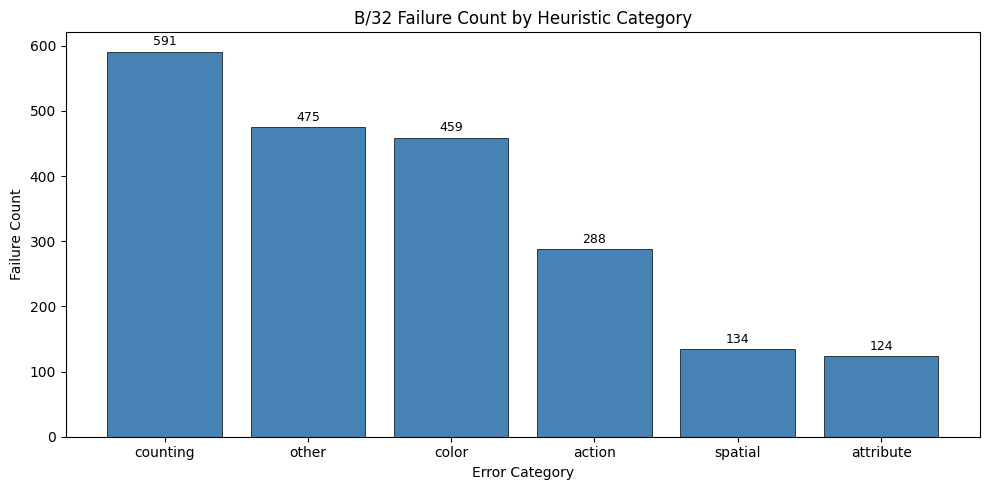

In [12]:
# Bar chart of failure counts by category
cats_sorted = [c for c, _ in category_counts.most_common()]
counts_sorted = [category_counts[c] for c in cats_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cats_sorted, counts_sorted, color="steelblue", edgecolor="black", linewidth=0.5)
for bar, count in zip(bars, counts_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Error Category")
ax.set_ylabel("Failure Count")
ax.set_title("B/32 Failure Count by Heuristic Category")
fig.tight_layout()
plt.show()

In [13]:
# Mean rank per category
category_ranks = defaultdict(list)
for case in failure_cases:
    category_ranks[case["category"]].append(case["gt_rank"])

print("Mean rank per error category:")
print(f"{'Category':>12} {'Mean Rank':>10} {'Median Rank':>12} {'Count':>8}")
print("-" * 44)
for cat in cats_sorted:
    ranks_cat = np.array(category_ranks[cat])
    print(f"{cat:>12} {ranks_cat.mean():>10.1f} {np.median(ranks_cat):>12.1f} {len(ranks_cat):>8d}")

Mean rank per error category:
    Category  Mean Rank  Median Rank    Count
--------------------------------------------
    counting       12.5          3.0      591
       other       12.5          3.0      475
       color       12.5          3.0      459
      action       10.0          3.0      288
     spatial       12.5          3.0      134
   attribute       13.5          3.0      124


## 5. Detailed Failure Visualization


--- Category: counting (591 failures) ---
  rank= 385  'A woman and three children .'
  rank= 324  'A group of people are sitting in chairs .'
  rank= 203  'Two boys playing ball in the street .'


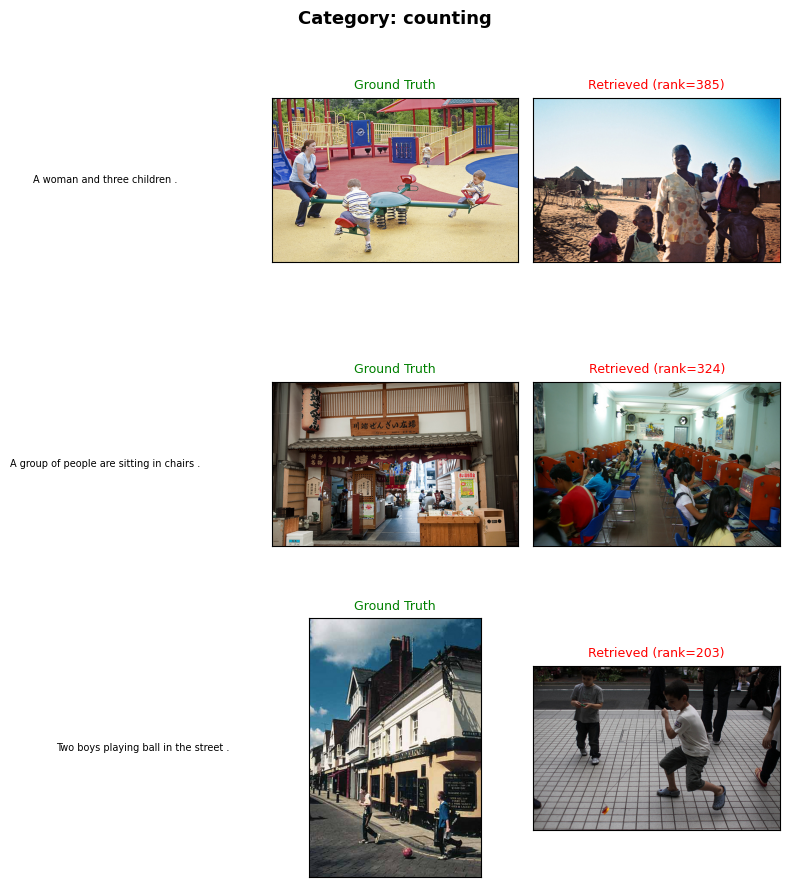


--- Category: other (475 failures) ---
  rank= 429  'This man and women lost something and is looking for it .'
  rank= 360  'Have a quick chat and smoke break .'
  rank= 233  'We have to go there to look into the machine .'


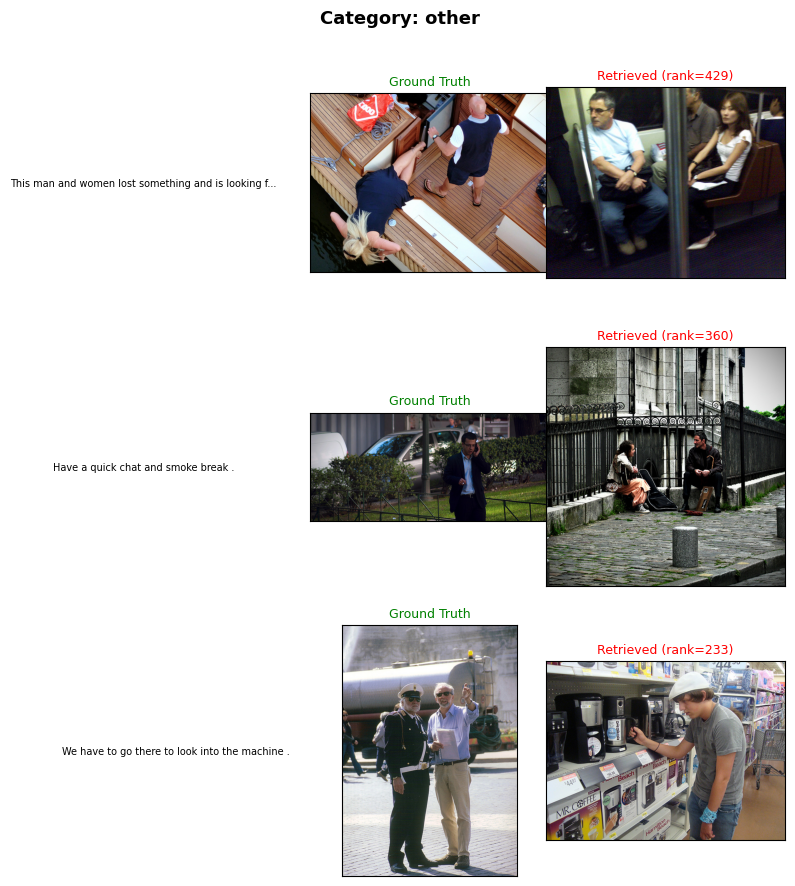


--- Category: color (459 failures) ---
  rank= 374  'A man is drinking out of a yellow cup .'
  rank= 295  'Blond man crossing street  in white shirt and red t-shirt  carrying a ...'
  rank= 184  'A young man wearing a blue jacket is turning his head .'


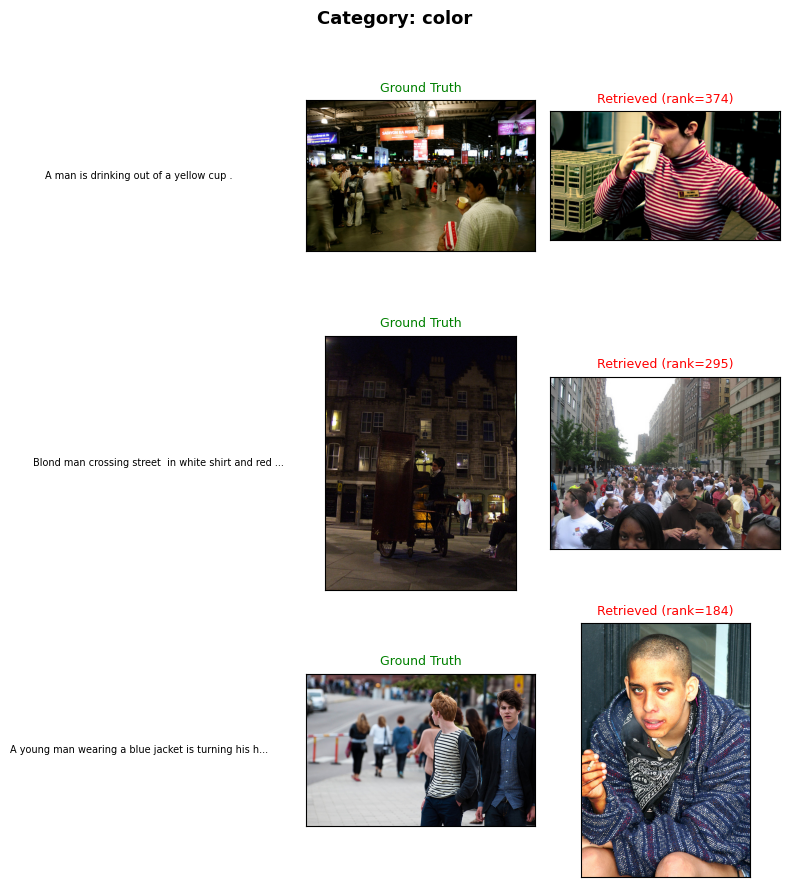


--- Category: action (288 failures) ---
  rank= 110  'A man wearing sunglasses is riding a scooter .'
  rank=  99  'A boy riding his scooter with sunglasses on .'
  rank=  87  'A man jumping onto a platform .'


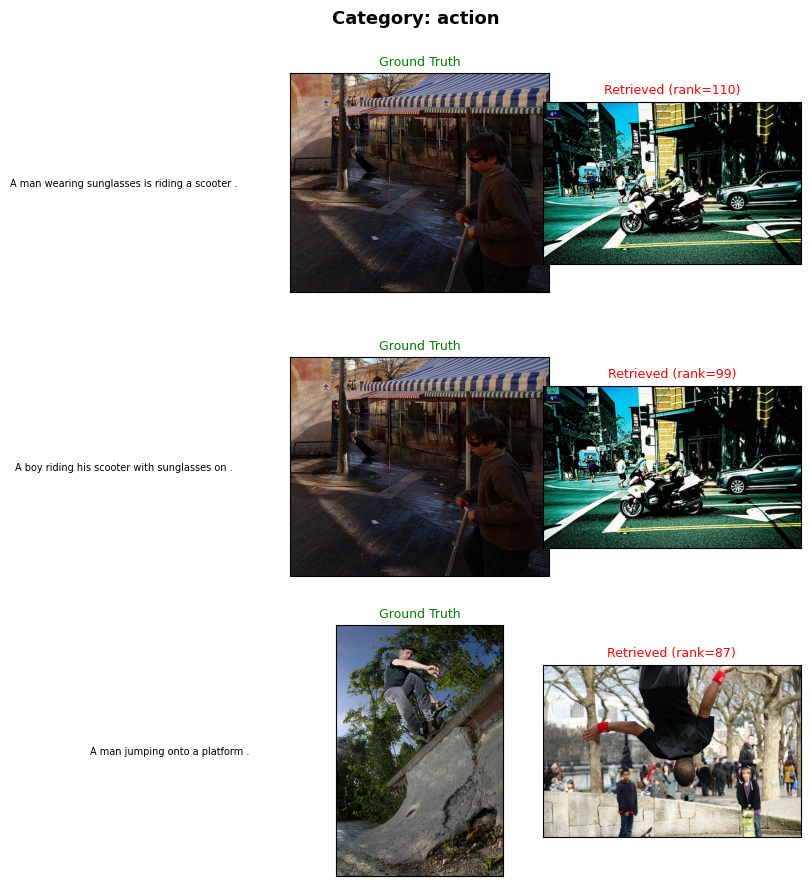

In [14]:
# Show 3 examples from each of the top 4 categories
top_categories = [c for c, _ in category_counts.most_common(4)]

for cat in top_categories:
    cat_cases = [c for c in failure_cases if c["category"] == cat]
    # Sort by rank descending to show worst failures
    cat_cases_sorted = sorted(cat_cases, key=lambda x: x["gt_rank"], reverse=True)
    examples = cat_cases_sorted[:3]

    print(f"\n--- Category: {cat} ({len(cat_cases)} failures) ---")
    for ex in examples:
        print(f"  rank={ex['gt_rank']:>4d}  '{ex['query_text'][:70]}...'" if len(ex["query_text"]) > 70
              else f"  rank={ex['gt_rank']:>4d}  '{ex['query_text']}'")

    fig = plot_error_analysis_grid(examples, test_ds, n_cols=2, n_rows=3)
    fig.suptitle(f"Category: {cat}", fontsize=13, fontweight="bold")
    plt.show()

## 6. Cross-Model Failure Comparison

In [15]:
b32_fail = ranks_b32 > 0
b16_fail = ranks_b16 > 0

b32_only = b32_fail & ~b16_fail  # B/32 fails, B/16 succeeds
b16_only = b16_fail & ~b32_fail  # B/16 fails, B/32 succeeds
shared_fail = b32_fail & b16_fail  # both fail
both_ok = ~b32_fail & ~b16_fail  # both succeed

print(f"B/32 only failures: {b32_only.sum():5d} ({b32_only.sum() / n_total * 100:.1f}%)")
print(f"B/16 only failures: {b16_only.sum():5d} ({b16_only.sum() / n_total * 100:.1f}%)")
print(f"Shared failures:    {shared_fail.sum():5d} ({shared_fail.sum() / n_total * 100:.1f}%)")
print(f"Both succeed:       {both_ok.sum():5d} ({both_ok.sum() / n_total * 100:.1f}%)")

B/32 only failures:   626 (12.5%)
B/16 only failures:   452 (9.0%)
Shared failures:     1445 (28.9%)
Both succeed:        2477 (49.5%)


B/32-only failures (B/16 gets these right):
  rank=  16  'The person in the striped shirt is mountain climbing .'
  rank=   7  'Employee in pink shirt smiles for camera inside a restaurant kitchen .'


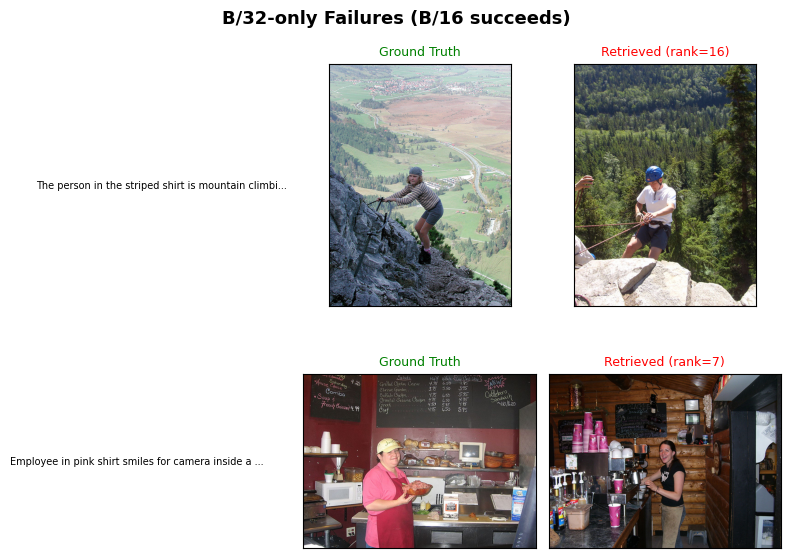

In [16]:
# Examples of B/32-only failures
b32_only_idx = np.where(b32_only)[0]
b32_only_cases = []
for i in b32_only_idx[:20]:  # search within first 20 for interesting ones
    top1 = text_to_image_search(txt_emb_b32[i], img_emb_b32, top_k=1)
    b32_only_cases.append({
        "query_idx": int(i),
        "query_text": captions[i],
        "gt_idx": int(gt_indices[i]),
        "gt_rank": int(ranks_b32[i]),
        "retrieved_idx": int(top1[0][0]),
    })

# Sort by rank desc, take top 2
b32_only_cases.sort(key=lambda x: x["gt_rank"], reverse=True)
b32_only_show = b32_only_cases[:2]

print("B/32-only failures (B/16 gets these right):")
for c in b32_only_show:
    print(f"  rank={c['gt_rank']:>4d}  '{c['query_text'][:80]}'")

if len(b32_only_show) > 0:
    fig = plot_error_analysis_grid(b32_only_show, test_ds, n_cols=2, n_rows=len(b32_only_show))
    fig.suptitle("B/32-only Failures (B/16 succeeds)", fontsize=13, fontweight="bold")
    plt.show()

B/16-only failures (B/32 gets these right):
  rank=  30  'A man in a military-type uniform is standing in the street listening to another '
  rank=  13  'A man in dressy clothes instructed a captain near a large truck .'


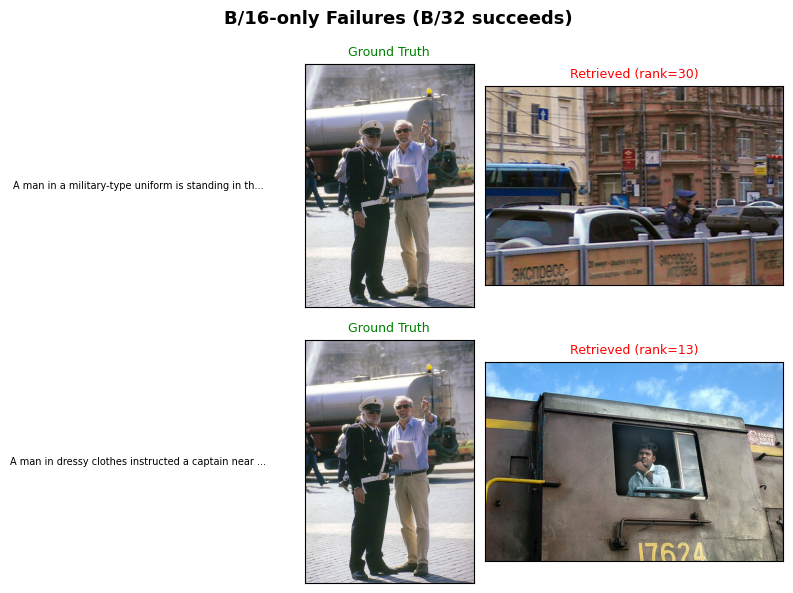

In [17]:
# Examples of B/16-only failures
b16_only_idx = np.where(b16_only)[0]
b16_only_cases = []
for i in b16_only_idx[:20]:
    top1 = text_to_image_search(txt_emb_b16[i], img_emb_b16, top_k=1)
    b16_only_cases.append({
        "query_idx": int(i),
        "query_text": captions[i],
        "gt_idx": int(gt_indices[i]),
        "gt_rank": int(ranks_b16[i]),
        "retrieved_idx": int(top1[0][0]),
    })

b16_only_cases.sort(key=lambda x: x["gt_rank"], reverse=True)
b16_only_show = b16_only_cases[:2]

print("B/16-only failures (B/32 gets these right):")
for c in b16_only_show:
    print(f"  rank={c['gt_rank']:>4d}  '{c['query_text'][:80]}'")

if len(b16_only_show) > 0:
    fig = plot_error_analysis_grid(b16_only_show, test_ds, n_cols=2, n_rows=len(b16_only_show))
    fig.suptitle("B/16-only Failures (B/32 succeeds)", fontsize=13, fontweight="bold")
    plt.show()

## 7. Hardness Analysis

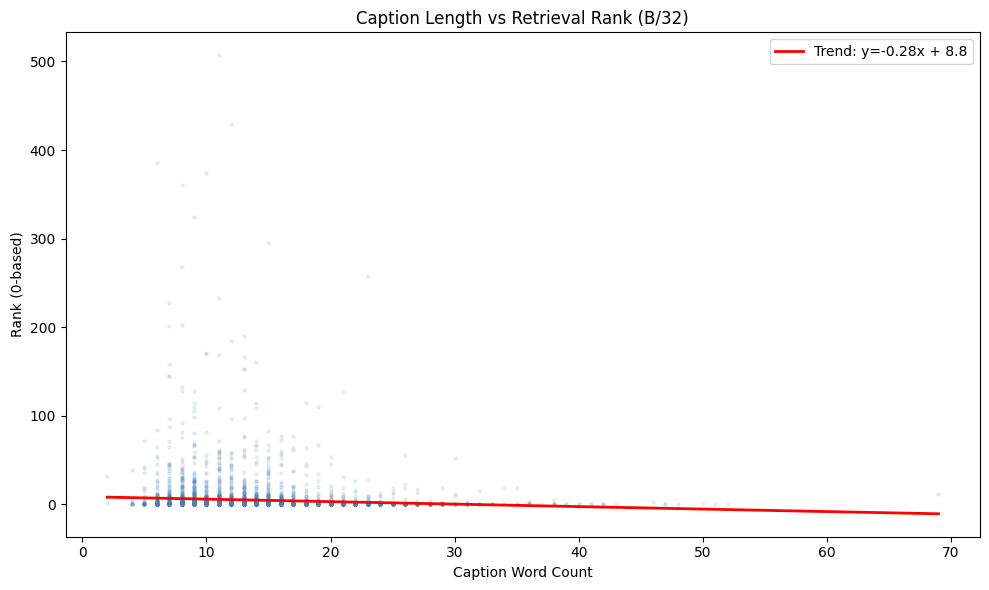

Pearson correlation (word count vs rank): -0.0701


In [18]:
# Caption length vs rank
word_counts = np.array([len(cap.split()) for cap in captions])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(word_counts, ranks_b32, alpha=0.1, s=5, color="steelblue")

# Trend line
z = np.polyfit(word_counts, ranks_b32, 1)
p = np.poly1d(z)
x_line = np.linspace(word_counts.min(), word_counts.max(), 100)
ax.plot(x_line, p(x_line), color="red", linewidth=2, label=f"Trend: y={z[0]:.2f}x + {z[1]:.1f}")

ax.set_xlabel("Caption Word Count")
ax.set_ylabel("Rank (0-based)")
ax.set_title("Caption Length vs Retrieval Rank (B/32)")
ax.legend()
fig.tight_layout()
plt.show()

# Correlation
corr = np.corrcoef(word_counts, ranks_b32)[0, 1]
print(f"Pearson correlation (word count vs rank): {corr:.4f}")

In [19]:
# Mean rank by caption length bucket
short_mask = word_counts < 8
medium_mask = (word_counts >= 8) & (word_counts <= 15)
long_mask = word_counts > 15

buckets = [
    ("Short (<8 words)", short_mask),
    ("Medium (8-15 words)", medium_mask),
    ("Long (>15 words)", long_mask),
]

print(f"{'Bucket':<22} {'Count':>7} {'Mean Rank':>10} {'Median Rank':>12} {'R@1':>8}")
print("-" * 62)
for name, mask in buckets:
    bucket_ranks = ranks_b32[mask]
    r1 = (bucket_ranks == 0).mean() * 100
    print(f"{name:<22} {mask.sum():>7d} {bucket_ranks.mean():>10.1f} {np.median(bucket_ranks):>12.1f} {r1:>7.1f}%")

Bucket                   Count  Mean Rank  Median Rank      R@1
--------------------------------------------------------------
Short (<8 words)           403        9.1          1.0    48.6%
Medium (8-15 words)       3310        5.4          0.0    57.4%
Long (>15 words)          1287        3.0          0.0    64.8%


## 8. Similarity Analysis of Hard Cases

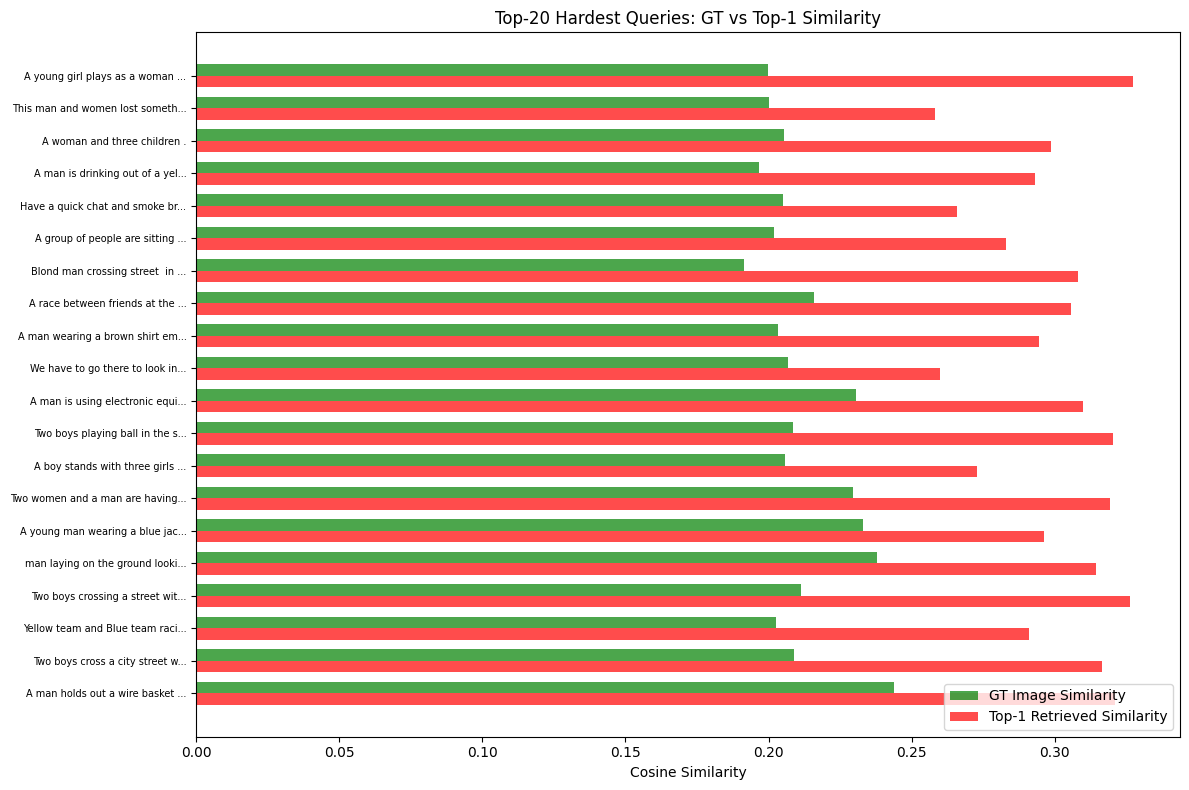

Mean similarity gap (top1 - GT): 0.0872
Max similarity gap: 0.1275
Min similarity gap: 0.0530


In [20]:
# Top-20 hardest queries (highest rank)
hardest_idx = np.argsort(ranks_b32)[::-1][:20]

# Compute similarity matrix for these queries
sim_matrix = get_similarity_scores(txt_emb_b32, img_emb_b32)

gt_sims = []
top1_sims = []
query_labels = []

for idx in hardest_idx:
    gt_sim = float(sim_matrix[idx, gt_indices[idx]])
    top1_img_idx = np.argmax(sim_matrix[idx])
    top1_sim = float(sim_matrix[idx, top1_img_idx])

    gt_sims.append(gt_sim)
    top1_sims.append(top1_sim)
    label = captions[idx][:30] + ("..." if len(captions[idx]) > 30 else "")
    query_labels.append(label)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(hardest_idx))
bar_height = 0.35

ax.barh(y_pos - bar_height / 2, gt_sims, bar_height, label="GT Image Similarity", color="green", alpha=0.7)
ax.barh(y_pos + bar_height / 2, top1_sims, bar_height, label="Top-1 Retrieved Similarity", color="red", alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(query_labels, fontsize=7)
ax.set_xlabel("Cosine Similarity")
ax.set_title("Top-20 Hardest Queries: GT vs Top-1 Similarity")
ax.legend(loc="lower right")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

# How close are they?
sim_gaps = np.array(top1_sims) - np.array(gt_sims)
print(f"Mean similarity gap (top1 - GT): {sim_gaps.mean():.4f}")
print(f"Max similarity gap: {sim_gaps.max():.4f}")
print(f"Min similarity gap: {sim_gaps.min():.4f}")

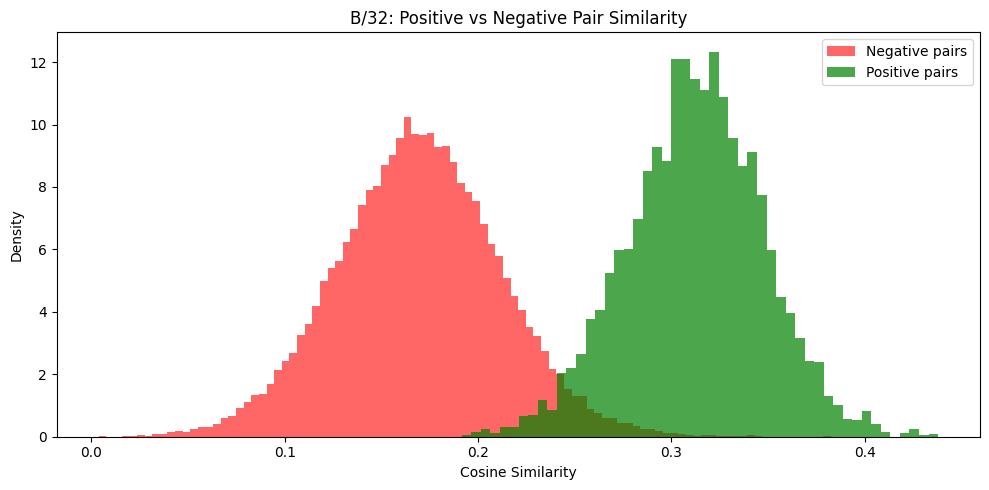

In [21]:
# Full positive vs negative similarity distribution
fig = plot_text_image_similarity_distribution(
    txt_emb_b32, img_emb_b32, gt_indices,
    title="B/32: Positive vs Negative Pair Similarity"
)
plt.show()

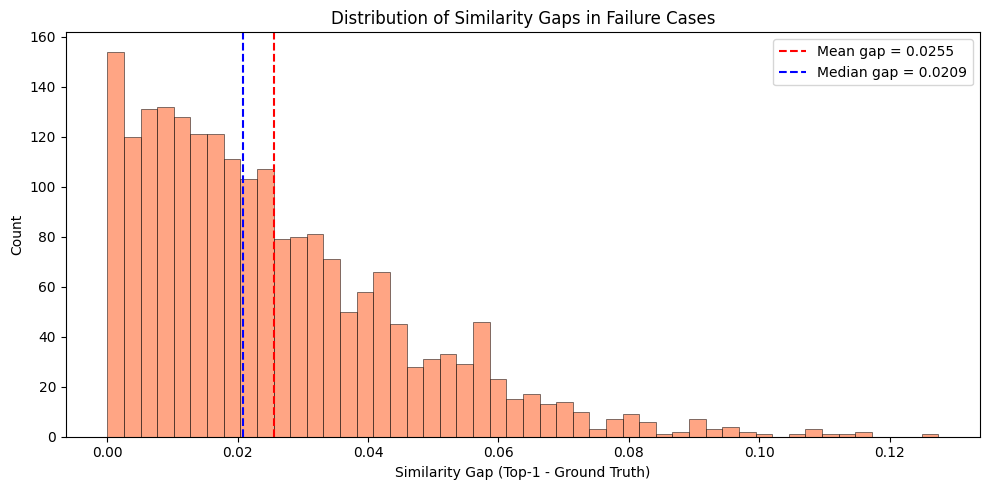

Failures with similarity gap < 0.05: 1805 (87.2%)
These are 'near misses' where fine-tuning could flip the ranking.


In [22]:
# Analyze near-miss similarity gaps for all failures
failure_gt_sims = []
failure_top1_sims = []

for case in failure_cases:
    i = case["query_idx"]
    gt_sim = float(sim_matrix[i, case["gt_idx"]])
    top1_sim = float(sim_matrix[i, case["retrieved_idx"]])
    failure_gt_sims.append(gt_sim)
    failure_top1_sims.append(top1_sim)

failure_gt_sims = np.array(failure_gt_sims)
failure_top1_sims = np.array(failure_top1_sims)
gaps = failure_top1_sims - failure_gt_sims

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gaps, bins=50, alpha=0.7, edgecolor="black", linewidth=0.5, color="coral")
ax.axvline(np.mean(gaps), color="red", linestyle="--", label=f"Mean gap = {np.mean(gaps):.4f}")
ax.axvline(np.median(gaps), color="blue", linestyle="--", label=f"Median gap = {np.median(gaps):.4f}")
ax.set_xlabel("Similarity Gap (Top-1 - Ground Truth)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Similarity Gaps in Failure Cases")
ax.legend()
fig.tight_layout()
plt.show()

# How many near-misses have very small gaps?
small_gap = (gaps < 0.05).sum()
print(f"Failures with similarity gap < 0.05: {small_gap} ({small_gap / len(gaps) * 100:.1f}%)")
print(f"These are 'near misses' where fine-tuning could flip the ranking.")

## 9. Summary & Motivation for Fine-Tuning

### Key Findings

**Error categories and prevalence:**
- The majority of failures involve captions with **action verbs**, **attributes**, and **counting** -- these require compositional understanding that CLIP's contrastive pre-training struggles with.
- **Color** and **spatial** errors are present but less dominant, suggesting CLIP has reasonable grounding for visual properties but still confuses similar scenes.
- A significant portion falls into "other" -- generic captions where CLIP simply retrieves a semantically similar but wrong image.

**What fine-tuning could address:**
- **Near-miss errors** (small similarity gaps between GT and top-1 retrieved) are the primary opportunity. Many failures have gaps < 0.05 -- a small push in the right direction during fine-tuning could correct these.
- **Compositional understanding** (counting, spatial relations, attributes) can improve with contrastive fine-tuning on hard negatives that differ in exactly these aspects.
- **Domain adaptation** -- fine-tuning on Flickr30k specifically adapts the embedding space to this dataset's distribution of scenes and captions.

**Motivation for hard negative mining:**
- The similarity gap analysis shows that many failures are "near misses" where a semantically similar but incorrect image outranks the correct one by a tiny margin.
- Hard negative mining (selecting training negatives that are close to the positive in embedding space) directly targets these cases, teaching the model to discriminate between visually similar images based on fine-grained textual cues.
- Cross-model comparison shows that B/32 and B/16 have partially complementary failure modes -- ensembling or architecture-aware fine-tuning could exploit this.

**Next steps (notebooks 04-06):**
- **04**: Fine-tuning setup with hard negative mining
- **05**: Training and evaluation of fine-tuned model
- **06**: Final comparison and analysis